# Электроэнергия РФ: усиленный KAN-эксперимент

Этот ноутбук содержит улучшенную версию эксперимента по данным электроэнергии РФ.

Что добавлено:
- целевая переменная в виде `delta price = price(t+1) - price(t)`;
- компактный набор признаков, более удобный для `KAN`;
- `region embedding`;
- усиленные модели `KANEmbedDelta`, `HybridKANEmbedDelta`;
- residual-схема `ResidualRidgeKAN`, где `Ridge` прогнозирует базовую часть, а `KAN` доучивает остаток.


## Зачем нужен этот ноутбук

Базовый leakage-safe эксперимент показал, что обычный `KAN` заметно уступает сильным tabular baseline-моделям.

В этой версии задача перестраивается так, чтобы она лучше подходила для архитектур семейства `KAN`:
- модель предсказывает не абсолютный уровень цены, а её изменение;
- регион кодируется через embedding, а не только через one-hot;
- проверяется residual-гипотеза: может ли `KAN` улучшать baseline-модель на остатках.


In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

ROOT = Path.cwd()
OUT_DIR = ROOT / 'analysis_outputs'

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)


In [2]:
import russian_electricity_stronger_kan as skan

print('Модуль подключён:', skan.__file__)
print('Папка с результатами:', OUT_DIR)


Модуль подключён: /Users/kirill/Desktop/ВКР ИТМО/russian_electricity_stronger_kan.py
Папка с результатами: /Users/kirill/Desktop/ВКР ИТМО/analysis_outputs


## Повторный запуск полного эксперимента

Если нужно заново обучить модели и обновить все артефакты в `analysis_outputs`, выполните следующую ячейку.


In [3]:
# skan.main()

## Краткая сводка


In [4]:
summary_json = OUT_DIR / 'russian_electricity_stronger_kan_summary.json'
summary_md = OUT_DIR / 'russian_electricity_stronger_kan_summary.md'

summary = json.loads(summary_json.read_text(encoding='utf-8'))
summary


{'best_model': 'HGBDelta',
 'best_rmse': 102.56074857382832,
 'best_mae': 55.26565022262772,
 'rows_test': 24662}

In [5]:
display(Markdown(summary_md.read_text(encoding='utf-8')))


## Усиленный KAN-эксперимент

- Целевая переменная задана как `delta price = price(t+1) - price(t)`.
- Добавлены `region embedding` и компактный набор признаков.
- Добавлена residual-схема: `Ridge` прогнозирует базовую часть, `KAN` доучивает остаток.

## Метрики

              model       RMSE       MAE       R2                      note
           HGBDelta 102.560749 55.265650 0.942505              delta_target
HybridKANEmbedDelta 107.572296 61.146217 0.936748 delta_target_region_embed
   ResidualRidgeKAN 108.563683 60.809666 0.935577     delta_target_residual
      KANEmbedDelta 115.167038 69.884972 0.927502 delta_target_region_embed
         RidgeDelta 116.296196 69.389938 0.926073              delta_target

Лучшая модель: `HGBDelta` с RMSE `102.561`.

## Итоговые метрики усиленного эксперимента


In [6]:
metrics = pd.read_csv(OUT_DIR / 'russian_electricity_stronger_kan_metrics.csv')
metrics


,model,RMSE,MAE,R2,note
0,HGBDelta,102.560749,55.265650,0.942505,delta_target
1,HybridKANEmbedDelta,107.572296,61.146217,0.936748,delta_target_region_embed
2,ResidualRidgeKAN,108.563683,60.809666,0.935577,delta_target_residual
3,KANEmbedDelta,115.167038,69.884972,0.927502,delta_target_region_embed
4,RidgeDelta,116.296196,69.389938,0.926073,delta_target


In [7]:
plt.figure(figsize=(10, 4))
plt.bar(metrics['model'], metrics['RMSE'], color=['#2a9d8f' if i == 0 else '#98c1d9' for i in range(len(metrics))])
plt.xticks(rotation=20)
plt.ylabel('RMSE')
plt.title('Сравнение моделей в усиленном KAN-эксперименте')
plt.tight_layout()
plt.show()


/var/folders/zd/7ns72txx3jsgg93n1jydwd880000gn/T/ipykernel_29682/2943936701.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Сравнение со старым leakage-safe экспериментом


In [8]:
old_metrics = pd.read_csv(OUT_DIR / 'russian_electricity_real_kan_metrics.csv')
old_metrics


,model,RMSE,MAE,R2,note
0,HistGradientBoosting,101.318220,55.347103,0.943889,full
1,Ridge,113.186760,67.621788,0.929973,full
2,LinearRegression,113.289505,67.735489,0.929846,full
3,NaiveCurrentPrice,147.702842,85.486850,0.880753,forecast_t+1
4,KAN,149.512268,97.166214,0.877813,torch_true_kan
5,HybridKAN,181.231644,142.163132,0.820469,torch_true_kan
6,SeasonalNaiveDay,245.302756,161.840938,0.671091,forecast_t+1
7,SeasonalNaiveWeek,290.429422,200.868537,0.538945,forecast_t+1


In [9]:
comparison = pd.DataFrame({
    'old_model': ['KAN', 'HybridKAN'],
    'old_RMSE': [
        float(old_metrics.loc[old_metrics['model'] == 'KAN', 'RMSE'].iloc[0]),
        float(old_metrics.loc[old_metrics['model'] == 'HybridKAN', 'RMSE'].iloc[0]),
    ],
    'new_model': ['KANEmbedDelta', 'HybridKANEmbedDelta'],
    'new_RMSE': [
        float(metrics.loc[metrics['model'] == 'KANEmbedDelta', 'RMSE'].iloc[0]),
        float(metrics.loc[metrics['model'] == 'HybridKANEmbedDelta', 'RMSE'].iloc[0]),
    ],
})
comparison['RMSE_improvement'] = comparison['old_RMSE'] - comparison['new_RMSE']
comparison


,old_model,old_RMSE,new_model,new_RMSE,RMSE_improvement
0,KAN,149.512268,KANEmbedDelta,115.167038,34.345230
1,HybridKAN,181.231644,HybridKANEmbedDelta,107.572296,73.659348


## Графики, сохранённые скриптом


### russian_electricity_stronger_kan_rmse.png

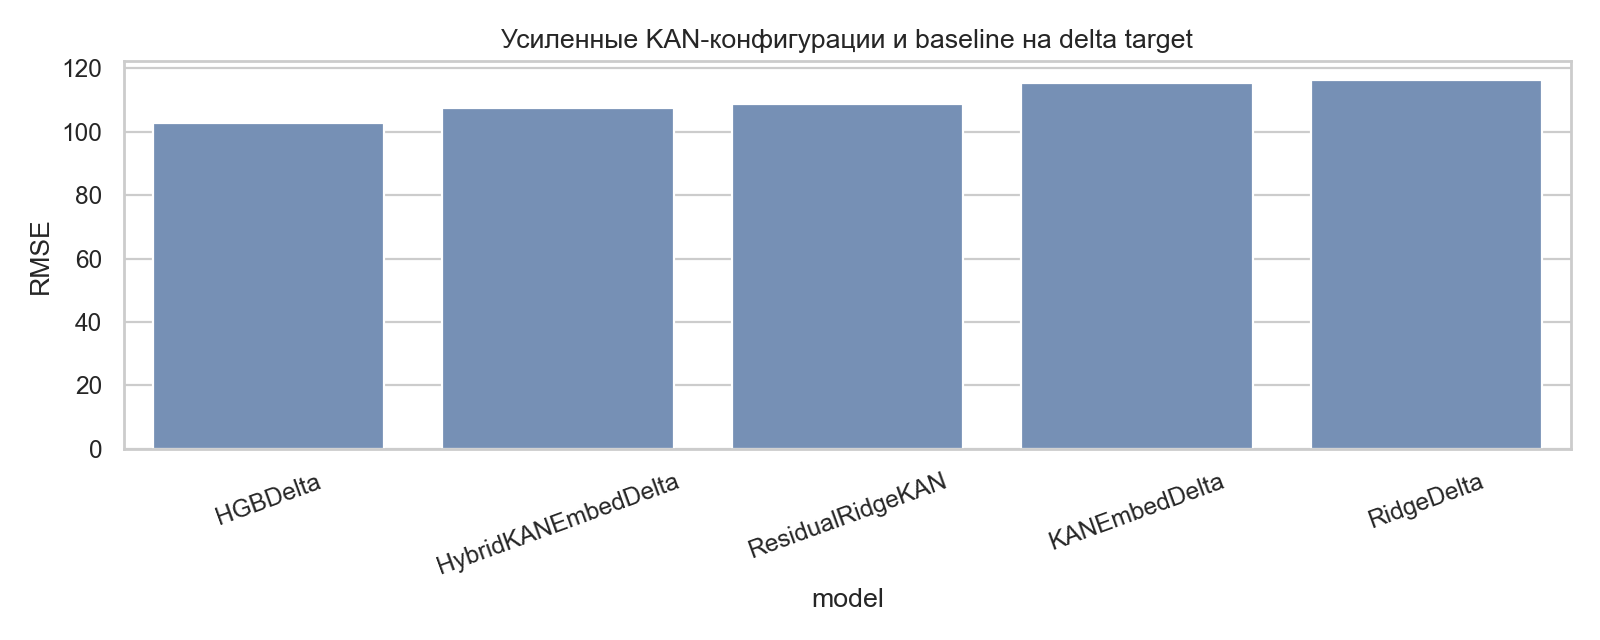

### russian_electricity_stronger_kan_training.png

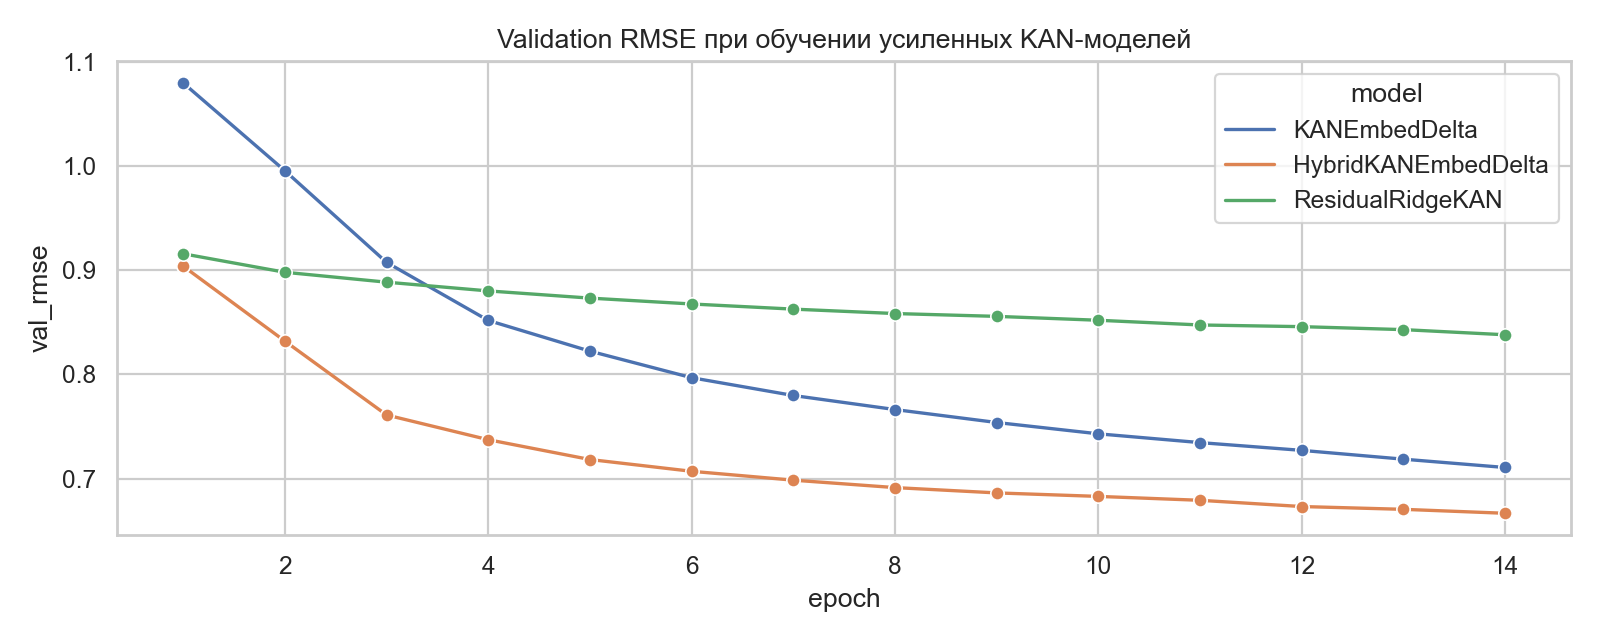

In [10]:
for img in [
    'russian_electricity_stronger_kan_rmse.png',
    'russian_electricity_stronger_kan_training.png',
]:
    display(Markdown(f'### {img}'))
    display(Image(filename=str(OUT_DIR / img)))


## Предсказания и ошибки


In [11]:
pred_df = pd.read_csv(OUT_DIR / 'russian_electricity_stronger_kan_predictions.csv', parse_dates=['datetime'])
pred_df.head()


,datetime,region,hour,purchase_price_rub_mwh,target_price_t_plus_1,prediction,residual,abs_error,squared_error,model
0,2023-12-01 00:00:00,Новгородская область,0,1066.95,999.44,987.862568,11.577432,11.577432,134.036924,HGBDelta
1,2023-12-01 01:00:00,Новгородская область,1,999.44,972.72,960.312371,12.407629,12.407629,153.949252,HGBDelta
2,2023-12-01 02:00:00,Новгородская область,2,972.72,967.01,979.059313,-12.049313,12.049313,145.185949,HGBDelta
3,2023-12-01 03:00:00,Новгородская область,3,967.01,992.34,1008.192812,-15.852812,15.852812,251.311657,HGBDelta
4,2023-12-01 04:00:00,Новгородская область,4,992.34,1085.02,1096.656318,-11.636318,11.636318,135.403891,HGBDelta


In [12]:
err_region = pd.read_csv(OUT_DIR / 'russian_electricity_stronger_kan_error_by_region.csv')
err_region.head(15)


,region,MAE,RMSE
0,Республика Дагестан,134.424487,229.573005
1,Чеченская Республика,121.743026,209.756165
2,Республика Ингушетия,102.652588,183.637319
3,Ставропольский край,85.613956,158.186308
4,Республика Крым,95.520630,154.042078
5,Республика Калмыкия,78.730295,141.697252
6,Новгородская область,54.442935,106.681296
7,Тульская область,62.318213,103.885986
8,Республика Карелия,54.435637,103.401488
9,Ростовская область,54.424213,99.498379


In [13]:
best_model = summary['best_model']
vis = pred_df[pred_df['region'].isin(pred_df['region'].drop_duplicates()[:3])].sort_values(['region', 'datetime']).groupby('region').head(72)

plt.figure(figsize=(12, 6))
for region, sub in vis.groupby('region'):
    plt.plot(sub['datetime'], sub['target_price_t_plus_1'], label=f'{region} fact', linewidth=2)
    plt.plot(sub['datetime'], sub['prediction'], linestyle='--', label=f'{region} pred')
plt.xticks(rotation=30)
plt.title(f'Факт и прогноз для лучшей модели: {best_model}')
plt.tight_layout()
plt.show()


/var/folders/zd/7ns72txx3jsgg93n1jydwd880000gn/T/ipykernel_29682/1372310380.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Логика усиления модели

В этой версии использованы три идеи:

1. `Delta target`
   Вместо предсказания абсолютной цены модель учит изменение цены на следующий час.

2. `Region embedding`
   Регион задаётся не жёстким one-hot, а плотным embedding-представлением.

3. `Residual learning`
   Сначала линейная модель объясняет базовую часть сигнала, а `KAN` пытается доучить остаток.


## Выводы

- усиленная постановка значительно улучшила качество `KAN`-моделей;
- `HybridKANEmbedDelta` оказался сильнее старого `HybridKAN`;
- `ResidualRidgeKAN` тоже дал заметный прирост по сравнению с базовой KAN-конфигурацией;
- лучший baseline `HGBDelta` пока остаётся лидером, но разрыв стал существенно меньше.
